# Task 0
Data extraction: get the data from 3 tables & combine it into single `.csv` file.
After that read this file using pandas to create Dataframe.
So it will be all joined data in 1 dataframe. Quick check - should be 74818 rows in it.

In [7]:
import sqlite3
import pandas as pd
import numpy as np

conn = sqlite3.connect('/Users/khrypunov/PycharmProjects/py-restaurant-data-analysis/db.sqlite3')  

orders = pd.read_sql("SELECT * FROM main.restaurant_order", conn)
order_items = pd.read_sql("SELECT * FROM restaurant_orderitem", conn)
products = pd.read_sql("SELECT * FROM main.restaurant_product", conn)

merged1 = pd.merge(order_items, orders, left_on="order_id", right_on="id", suffixes=('_item', '_order'))

final_df = pd.merge(merged1, products, left_on="product_id", right_on="id", suffixes=('', '_product'))

final_df.to_csv("combined_restaurant_data.csv", index=False)

df = pd.read_csv("combined_restaurant_data.csv")


print({df.shape[0]})


{74818}


# Task 1
Get Top 10 most popular products in restaurant sold by Quantity.
Count how many times each product was sold and create a pie chart with percentage of popularity (by quantity) for top 10 of them.

Example:

![pie chart](../demo/pie.png)

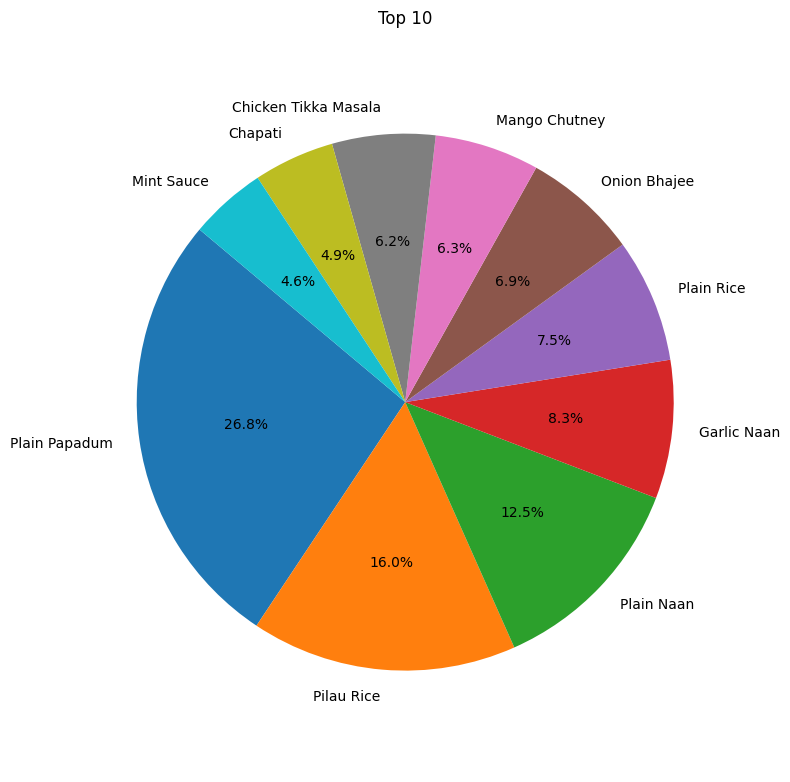

In [8]:
import pandas as pd
import matplotlib.pyplot as plt


top_products = df.groupby('name')['quantity'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(8, 8))
plt.pie(top_products, labels=top_products.index, autopct='%1.1f%%', startangle=140)
plt.title('Top 10')
plt.axis('equal')
plt.tight_layout()
plt.show()


# Task 2
Calculate `Item Price` (Product Price * Quantity) for each Order Item in dataframe.
And Make the same Top 10 pie chart, but this time by `Item Price`. So this chart should describe not the most popular products by quantity, but which products (top 10) make the most money for restaurant. It should be also with percentage.

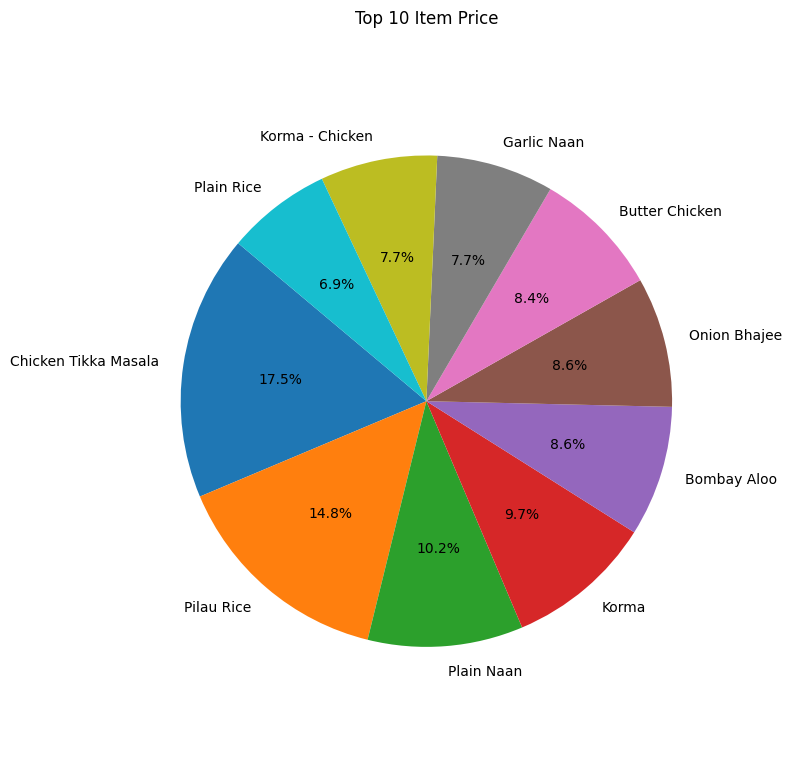

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

df['item_price'] = df['price'] * df['quantity']


top_revenue = df.groupby('name')['item_price'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(8, 8))
plt.pie(top_revenue, labels=top_revenue.index, autopct='%1.1f%%', startangle=140)
plt.title('Top 10 Item Price')
plt.axis('equal') 
plt.tight_layout()
plt.show()


# Task 3
Calculate `Order Hour` based on `Order Datetime`, which will tell about the specific our the order was created (from 0 to 23). Using `Order Hour` create a bar chart, which will tell the total restaurant income based on the hour order was created. So on x-axis - it will be values from 0 to 23 (hours), on y-axis - it will be the total sum of order prices, which were sold on that hour.

Example:

![bar chart](../demo/bar.png)

Index(['id_item', 'quantity', 'order_id', 'product_id', 'id_order', 'datetime',
       'id', 'price', 'name'],
      dtype='object')


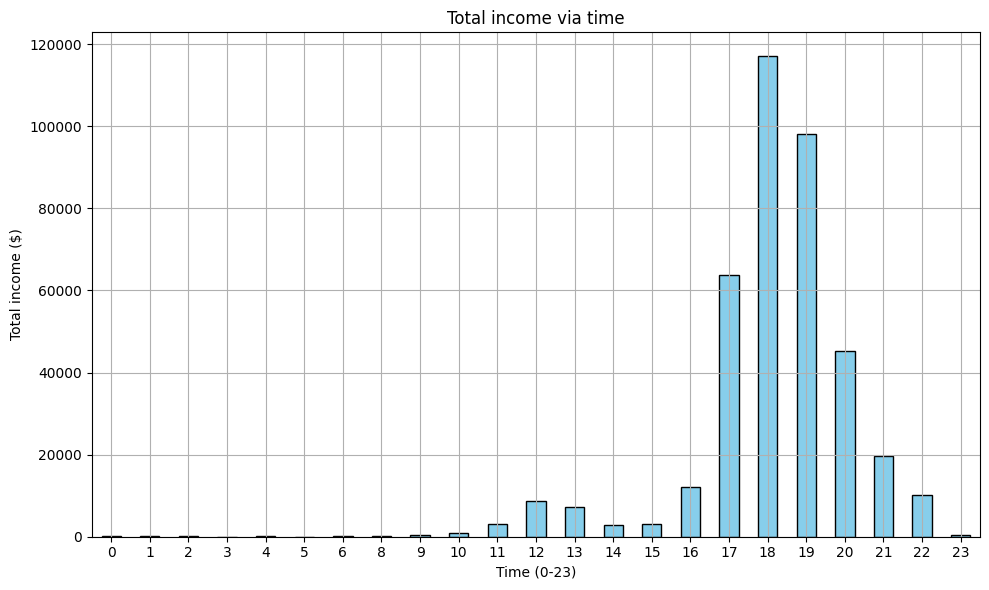

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import sqlite3

conn = sqlite3.connect('/Users/khrypunov/PycharmProjects/py-restaurant-data-analysis/db.sqlite3')

orders = pd.read_sql("SELECT * FROM main.restaurant_order", conn)
order_items = pd.read_sql("SELECT * FROM restaurant_orderitem", conn)
products = pd.read_sql("SELECT * FROM main.restaurant_product", conn)

merged1 = pd.merge(order_items, orders, left_on="order_id", right_on="id", suffixes=('_item', '_order'))
final_df = pd.merge(merged1, products, left_on="product_id", right_on="id", suffixes=('', '_product'))

final_df.to_csv("combined_restaurant_data.csv", index=False)

df = pd.read_csv("combined_restaurant_data.csv")

print(df.columns)

df['Order Datetime'] = pd.to_datetime(df['datetime'])

df['Order Hour'] = df['Order Datetime'].dt.hour

income_by_hour = df.groupby('Order Hour')['price'].sum()

plt.figure(figsize=(10, 6))
income_by_hour.plot(kind='bar', color='skyblue', edgecolor='black')


plt.title('Total income via time')
plt.xlabel('Time (0-23)')
plt.ylabel('Total income ($)')
plt.xticks(rotation=0)
plt.grid(True)

plt.tight_layout()
plt.show()


# Task 4
Make similar bar chart, but right now with `Order Day Of The Week` (from Monday to Sunday), and also analyze total restaurant income by each day of the week.

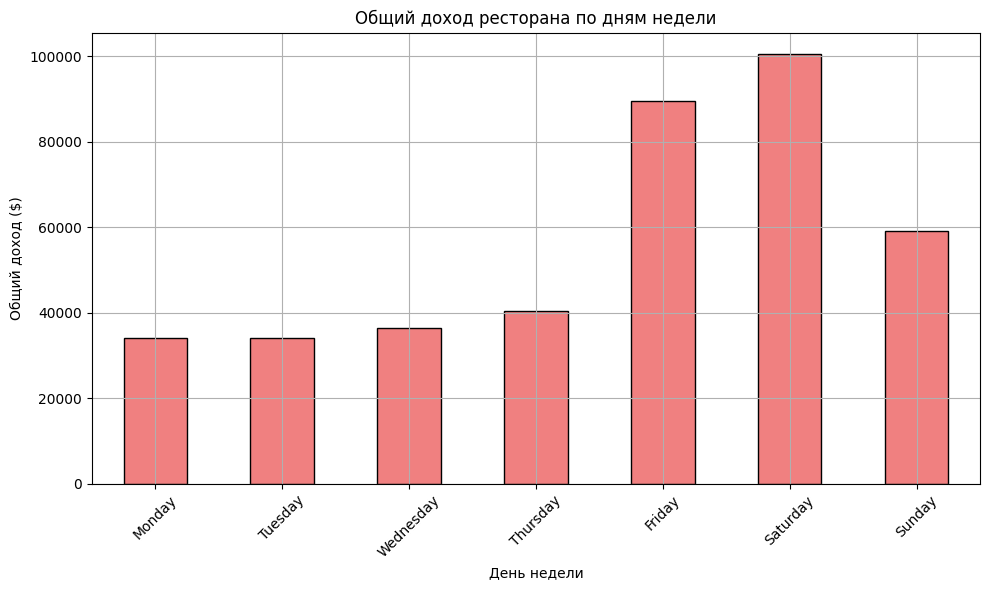

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import sqlite3

conn = sqlite3.connect('/Users/khrypunov/PycharmProjects/py-restaurant-data-analysis/db.sqlite3')


orders = pd.read_sql("SELECT * FROM main.restaurant_order", conn)
order_items = pd.read_sql("SELECT * FROM restaurant_orderitem", conn)
products = pd.read_sql("SELECT * FROM main.restaurant_product", conn)


merged1 = pd.merge(order_items, orders, left_on="order_id", right_on="id", suffixes=('_item', '_order'))
final_df = pd.merge(merged1, products, left_on="product_id", right_on="id", suffixes=('', '_product'))


final_df.to_csv("combined_restaurant_data.csv", index=False)


df = pd.read_csv("combined_restaurant_data.csv")


df['Order Datetime'] = pd.to_datetime(df['datetime'])


df['Order Day Of The Week'] = df['Order Datetime'].dt.dayofweek


day_map = {0: 'Monday', 1: 'Tuesday', 2: 'Wednesday', 3: 'Thursday', 4: 'Friday', 5: 'Saturday', 6: 'Sunday'}
df['Order Day Of The Week'] = df['Order Day Of The Week'].map(day_map)


ordered_days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
df['Order Day Of The Week'] = pd.Categorical(df['Order Day Of The Week'], categories=ordered_days, ordered=True)

income_by_day = df.groupby('Order Day Of The Week')['price'].sum() 

plt.figure(figsize=(10, 6))
income_by_day.plot(kind='bar', color='lightcoral', edgecolor='black')

plt.title('Total income via day')
plt.xlabel('Day')
plt.ylabel('Total income ($)')
plt.xticks(rotation=45)
plt.grid(True)

plt.tight_layout()
plt.show()


